In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, numpy as np
os.environ['OMP_NUM_THREADS'] = '12'  # 250608に合わせる（落ちるなら 1 に）
import matplotlib
import math
from matplotlib import pyplot as plt
import scipy

sys.path.append("/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/interface/")
import cosmolike_mg_hsc_y3_interface as ci
from getdist import IniFile

import ctypes
# 250608に合わせる
os.environ['LD_LIBRARY_PATH'] = '/home/tanida/anaconda3/lib'
ctypes.CDLL('/home/tanida/anaconda3/lib/libgfortran.so.4')

# CAMB
sys.path.insert(0, "/home/tanida/cocoa_v41/cocoa/Cocoa/external_modules/code/MGCAMB/build/lib")
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.2 installed at /home/tanida/cocoa_v41/cocoa/Cocoa/external_modules/code/MGCAMB/build/lib/camb


In [2]:
OUT_DIR = "/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/scripts"

# dataset（binningやlens/source ntomoを読むため）
path = "/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/data/"
data_file = "mg_hsc_y3_M2_3x2pt_all.dataset"

print("OUT_DIR:", OUT_DIR)
print("dataset:", os.path.join(path, data_file))

OUT_DIR: /home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/scripts
dataset: /home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/data/mg_hsc_y3_M2_3x2pt_all.dataset


In [3]:
# Planck_params 相当（あなたのVelocileptors比較と同じものを入れる）
ns = 0.96605
omegam = 0.314419
H0 = 67.32
omegab = 0.049389
mnu = 0.0
w0pwa = -1.0
w = -1.0

# MG
sigma0 = 0.0

# mu0ごとの As_1e9（あなたが計算した値で置き換え）
As_1e9_mu0 = {
    0.0: 2.2065,  # <- mu0=0.0 用
    1.0: 2.2065,  # <- mu0=1.0 用
}

# IAは0固定（3x2pt出力が欲しいだけなら）
IA_model = 0
IA_redshift_evolution = 0

In [4]:
# # # def get_camb_cosmology(omegam = omegam, omegab = omegab, H0 = H0, ns = ns, 
# # #                        As_1e9 = 2.2065, w = w, w0pwa = w0pwa, 
# # #                        mu0 = 0.0, sigma0 = 0.0,
# # #                        AccuracyBoost = 1.0, 
# # #                        kmax = 10, k_per_logint = 20, CAMBAccuracyBoost=1.5):

# # #     As = lambda As_1e9: 1e-9 * As_1e9
# # #     wa = lambda w0pwa, w: w0pwa - w
# # #     omegabh2 = lambda omegab, H0: omegab*(H0/100)**2
# # #     omegach2 = lambda omegam, omegab, mnu, H0: (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708

# # #     CAMBAccuracyBoost = CAMBAccuracyBoost*AccuracyBoost
# # #     kmax = max(kmax/2.0, kmax*(1.0 + 3*(AccuracyBoost-1)))
# # #     k_per_logint = max(k_per_logint/2.0, int(k_per_logint) + int(3*(AccuracyBoost-1)))
# # #     extrap_kmax = max(max(2.5e2, 3*kmax), max(2.5e2, 3*kmax) * AccuracyBoost)

# # #     z_interp_1D = np.concatenate((np.linspace(0,2.0,1000),
# # #                                   np.linspace(2.0,10.1,200),
# # #                                   np.linspace(1080,2000,20)), axis=0)
# # #     z_interp_2D = np.concatenate((np.linspace(0, 2.0, 95),
# # #                                   np.linspace(2.25, 10, 5)), axis=0)

# # #     log10k_interp_2D = np.linspace(-4.2, 2.0, 1200)

# # #     pars = camb.set_params(H0=H0, 
# # #                            ombh2=omegabh2(omegab, H0), 
# # #                            omch2=omegach2(omegam, omegab, mnu, H0), 
# # #                            mnu=mnu, 
# # #                            omk=0, 
# # #                            tau=0.06,  
# # #                            As=As(As_1e9), 
# # #                            ns=ns, 
# # #                            halofit_version='takahashi', 
# # #                            lmax=10,
# # #                            AccuracyBoost=CAMBAccuracyBoost,
# # #                            lens_potential_accuracy=1.0,
# # #                            num_massive_neutrinos=1,
# # #                            nnu=3.046,
# # #                            accurate_massive_neutrino_transfers=False,
# # #                            k_per_logint=k_per_logint,
# # #                            kmax = kmax)

# # #     pars.set_dark_energy(w=w, wa=wa(w0pwa, w), dark_energy_model='ppf')    
# # #     pars.NonLinear = model.NonLinear_both
# # #     pars.set_matter_power(redshifts = z_interp_2D, kmax = kmax, silent = True)
# # #     results = camb.get_results(pars)

# # #     # mu/Sigma table
# # #     z_mg_array = np.linspace(0, 4.0, 200)
# # #     omega_lambda_z = results.get_Omega('de', z=z_mg_array)
# # #     omega_lambda_0 = results.omega_de
# # #     mu_z    = 1.0 + mu0 * (omega_lambda_z / omega_lambda_0)
# # #     Sigma_z = 1.0 + sigma0 * (omega_lambda_z / omega_lambda_0)

# # #     PKL  = results.get_matter_power_interpolator(var1="delta_tot", var2="delta_tot", nonlinear = False, 
# # #                                                  extrap_kmax = extrap_kmax, hubble_units = False, k_hunit = False)
# # #     PKNL = results.get_matter_power_interpolator(var1="delta_tot", var2="delta_tot",  nonlinear = True, 
# # #                                                  extrap_kmax = extrap_kmax, hubble_units = False, k_hunit = False)

# # #     lnPL = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
# # #     for i in range(len(z_interp_2D)):
# # #         lnPL[i::len(z_interp_2D)] = np.log(PKL.P(z_interp_2D[i], np.power(10.0,log10k_interp_2D)))
# # #     lnPL  += np.log(((H0/100.)**3)) 

# # #     lnPNL  = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
# # #     for i in range(len(z_interp_2D)):
# # #         lnPNL[i::len(z_interp_2D)] = np.log(PKNL.P(z_interp_2D[i], np.power(10.0, log10k_interp_2D)))            
# # #     log10k_interp_2D = log10k_interp_2D - np.log10(H0/100.)
# # #     lnPNL += np.log(((H0/100.)**3))

# # #     G_growth = np.sqrt(PKL.P(z_interp_2D,0.0005)/PKL.P(0,0.0005))
# # #     G_growth = G_growth*(1 + z_interp_2D)/G_growth[len(G_growth)-1]

# # #     chi = results.comoving_radial_distance(z_interp_1D, tol=1e-4) * (H0/100.)

# # #     return (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
# # #             z_mg_array, mu_z, Sigma_z)


# # def get_camb_cosmology(omegam = omegam, omegab = omegab, H0 = H0, ns = ns, 
# #                        As_1e9 = 2.2065, w = w, w0pwa = w0pwa, 
# #                        mu0 = 0.0, sigma0 = 0.0,
# #                        AccuracyBoost = 1.0, 
# #                        kmax = 10, k_per_logint = 20, CAMBAccuracyBoost=1.5):

# #     As = lambda As_1e9: 1e-9 * As_1e9
# #     wa = lambda w0pwa, w: w0pwa - w
# #     omegabh2 = lambda omegab, H0: omegab*(H0/100)**2
# #     omegach2 = lambda omegam, omegab, mnu, H0: (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708

# #     pars = camb.set_params(H0=H0, 
# #                            ombh2=omegabh2(omegab, H0), 
# #                            omch2=omegach2(omegam, omegab, mnu, H0), 
# #                            mnu=mnu, As=As(As_1e9), ns=ns, 
# #                            halofit_version='takahashi',
# #                            AccuracyBoost=CAMBAccuracyBoost*AccuracyBoost,
# #                            kmax = kmax)

# #     # --- ★ここが重要：MGCAMB を有効にする設定を追加 ---
# #     pars.MG_wrapped = True
# #     pars.set_mgparams(
# #         MG_flag = 1,        # MGCAMBを有効化
# #         pure_MG_flag = 2,   # mu-Sigma パラメータ化を使用
# #         muSigma_flag = 1,   # 摂動のみ MG
# #         mu0 = mu0, 
# #         sigma0 = sigma0,
# #         GRtrans = 0.01      # GRからの遷移赤方偏移（十分大きく）
# #     )
# #     # ----------------------------------------------

# #     pars.set_dark_energy(w=w, wa=wa(w0pwa, w), dark_energy_model='ppf')    
# #     pars.NonLinear = model.NonLinear_both
    
# #     z_interp_2D = np.concatenate((np.linspace(0, 2.0, 95), np.linspace(2.25, 10, 5)),  axis=0)
# #     pars.set_matter_power(redshifts = z_interp_2D, kmax = kmax, silent = True)
# #     results = camb.get_results(pars)

# #     # mu/Sigma table (CosmoLike への受け渡し用)
# #     z_mg_array = np.linspace(0, 4.0, 200)
# #     omega_lambda_z = results.get_Omega('de', z=z_mg_array)
# #     omega_lambda_0 = results.omega_de
# #     mu_z    = 1.0 + mu0 * (omega_lambda_z / omega_lambda_0)
# #     Sigma_z = 1.0 + sigma0 * (omega_lambda_z / omega_lambda_0)

# #     # パワースペクトル抽出
# #     PKL  = results.get_matter_power_interpolator(nonlinear = False, hubble_units = False, k_hunit = False)
# #     PKNL = results.get_matter_power_interpolator(nonlinear = True,  hubble_units = False, k_hunit = False)

# #     log10k_interp_2D = np.linspace(-4.2, 2.0, 1200)
# #     # lnPL = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
# #     # for i in range(len(z_interp_2D)):
# #     #     lnPL[i::len(z_interp_2D)] = np.log(PKL.P(z_interp_2D[i], np.power(10.0,log10k_interp_2D)))
# #     # lnPL  += np.log(((H0/100.)**3)) 
# #     # 非線形テーブルを計算する箇所を修正
# #     lnPNL = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
# #     for i in range(len(z_interp_2D)):
# #         # ★ここを lnPL に書き換えて強制的に Linear にする
# #         lnPNL[i::len(z_interp_2D)] = np.log(PKL.P(z_interp_2D[i], np.power(10.0, log10k_interp_2D)))
    
# #     lnPNL += np.log(((H0/100.)**3))

# #     lnPNL  = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
# #     for i in range(len(z_interp_2D)):
# #         lnPNL[i::len(z_interp_2D)] = np.log(PKNL.P(z_interp_2D[i], np.power(10.0, log10k_interp_2D)))            
# #     lnPNL += np.log(((H0/100.)**3))

# #     G_growth = np.sqrt(PKL.P(z_interp_2D,0.0005)/PKL.P(0,0.0005))
# #     G_growth = G_growth*(1 + z_interp_2D)/G_growth[len(G_growth)-1]

# #     z_interp_1D = np.linspace(0, 10.99, 1000)
# #     chi = results.comoving_radial_distance(z_interp_1D) * (H0/100.)

# #     return (log10k_interp_2D - np.log10(H0/100.), z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
# #             z_mg_array, mu_z, Sigma_z)

# def get_camb_cosmology(mu0=0.0, sigma0=0.0, target_sigma8=0.8120):
#     # ユーザー指定の Planck パラメータ
#     h = 0.6732
#     ob = 0.049389
#     oc = 0.26503
#     ns = 0.96605
#     H0 = h * 100
    
#     # 1. 準備段階： baseline As=2.1e-9 で sigma8 を確認
#     params_camb = camb.CAMBparams()
#     params_camb.set_cosmology(H0=H0, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
#     params_camb.MG_wrapped = True
#     params_camb.MG_flag = 1
#     params_camb.pure_MG_flag = 2
#     params_camb.muSigma_par = 1
#     params_camb.mu0 = mu0
#     params_camb.sigma0 = sigma0
#     params_camb.InitPower.set_params(As=2.1e-09, ns=ns)
    
#     # z=0.0 での sigma8 を計算
#     params_camb.set_matter_power(redshifts=[0.0], kmax=20.0, nonlinear=False)
#     results = camb.get_results(params_camb)
#     s8_z0 = results.get_sigma8_0()
    
#     # As をスケーリング (As \propto sigma8^2)
#     new_As = 2.1e-09 * (target_sigma8 / s8_z0)**2
#     params_camb.InitPower.set_params(As=new_As, ns=ns)
    
#     # 2. 本計算： 補正後の As で全テーブルを作成
#     z_interp_2D = np.concatenate((np.linspace(0, 2.0, 95), np.linspace(2.25, 10, 5)), axis=0)
#     params_camb.set_matter_power(redshifts=z_interp_2D, kmax=20.0, nonlinear=False)
#     results = camb.get_results(params_camb)
    
#     print(f"mu0={mu0:.1f} | target s8={target_sigma8} | Scaled As_1e9: {new_As*1e9:.6f} | Final s8(z=0): {results.get_sigma8_0():.4f}")

#     # mu-Sigma table (CosmoLike用)
#     z_mg_array = np.linspace(0, 4.0, 200)
#     omega_lambda_z = results.get_Omega('de', z=z_mg_array)
#     omega_lambda_0 = results.omega_de
#     mu_z    = 1.0 + mu0 * (omega_lambda_z / omega_lambda_0)
#     Sigma_z = 1.0 + sigma0 * (omega_lambda_z / omega_lambda_0)

#     # パワースペクトル抽出
#     PKL = results.get_matter_power_interpolator(nonlinear=False, hubble_units=False, k_hunit=False)
    
#     log10k_interp_2D = np.linspace(-4.2, 2.0, 1200)
#     lnPL = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
#     for i in range(len(z_interp_2D)):
#         lnPL[i::len(z_interp_2D)] = np.log(PKL.P(z_interp_2D[i], np.power(10.0, log10k_interp_2D)))
    
#     # CosmoLike 単位変換 (h^3 スケール)
#     lnPL += np.log((h**3)) 
#     lnPNL = lnPL.copy() # 強制 Linear 同士の比較

#     G_growth = np.sqrt(PKL.P(z_interp_2D, 0.0005) / PKL.P(0, 0.0005))
#     G_growth = G_growth * (1 + z_interp_2D) / G_growth[len(G_growth)-1]

#     z_interp_1D = np.linspace(0, 10.99, 1000)
#     chi = results.comoving_radial_distance(z_interp_1D) * h

#     return (log10k_interp_2D - np.log10(h), z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
#             z_mg_array, mu_z, Sigma_z)
def get_camb_cosmology(mu0=0.0, sigma0=0.0, target_sigma8=0.8120):
    # ユーザー指定の Planck パラメータ
    h = 0.6732
    ob = 0.049389
    oc = 0.26503
    ns = 0.96605
    H0 = h * 100
    
    params_camb = camb.CAMBparams()
    # 基本的な宇宙論の設定
    params_camb.set_cosmology(H0=H0, ombh2=ob*h**2, omch2=oc*h**2, mnu=0.0, omk=0, tau=0.0697186, nnu=3.046)
    
    # MGCAMB設定
    params_camb.MG_wrapped = True
    params_camb.MG_flag = 1
    params_camb.pure_MG_flag = 2
    params_camb.muSigma_par = 1
    params_camb.mu0 = mu0
    params_camb.sigma0 = sigma0
    
    # 1. z=0.0でのsigma8を確認してAsをスケール (ユーザー指定のロジック)
    params_camb.InitPower.set_params(As=2.1e-09, ns=ns)
    # ここで set_matter_power を呼ぶことで WantTransfer フラグが立ち、AssertionError を回避します
    params_camb.set_matter_power(redshifts=[0.0], kmax=50.0, nonlinear=False)
    
    results = camb.get_results(params_camb)
    s8_z0 = results.get_sigma8_0()
    
    # As をスケーリング
    new_As = 2.1e-09 * (target_sigma8 / s8_z0)**2
    params_camb.InitPower.set_params(As=new_As, ns=ns)
    
    # 2. 本計算： 補正後の As で全テーブルを作成
    z_interp_2D = np.concatenate((np.linspace(0, 2.0, 95), np.linspace(2.25, 10, 5)), axis=0)
    params_camb.set_matter_power(redshifts=z_interp_2D, kmax=50.0, nonlinear=False)
    results = camb.get_results(params_camb)
    
    print(f"mu0={mu0:.1f} | Final s8(z=0): {results.get_sigma8_0():.4f} | As_1e9: {new_As*1e9:.6f}")

    # --- 以下、CosmoLike への受け渡し処理 ---
    
    # mu-Sigma table
    z_mg_array = np.linspace(0, 4.0, 200)
    omega_lambda_z = results.get_Omega('de', z=z_mg_array)
    omega_lambda_0 = results.omega_de
    mu_z    = 1.0 + mu0 * (omega_lambda_z / omega_lambda_0)
    Sigma_z = 1.0 + sigma0 * (omega_lambda_z / omega_lambda_0)

    # パワースペクトル抽出
    PKL = results.get_matter_power_interpolator(nonlinear=False, hubble_units=False, k_hunit=False)
    
    log10k_interp_2D = np.linspace(-4.2, 2.0, 1200)
    lnPL = np.empty(len(log10k_interp_2D)*len(z_interp_2D))
    for i in range(len(z_interp_2D)):
        lnPL[i::len(z_interp_2D)] = np.log(PKL.P(z_interp_2D[i], np.power(10.0, log10k_interp_2D)))
    
    lnPL += np.log((h**3)) # CosmoLike 単位変換
    lnPNL = lnPL.copy()    # 強制 Linear

    G_growth = np.sqrt(PKL.P(z_interp_2D, 0.0005) / PKL.P(0, 0.0005))
    G_growth = G_growth * (1 + z_interp_2D) / G_growth[len(G_growth)-1]

    z_interp_1D = np.linspace(0, 10.99, 1000)
    chi = results.comoving_radial_distance(z_interp_1D) * h

    return (log10k_interp_2D - np.log10(h), z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
            z_mg_array, mu_z, Sigma_z)

In [5]:
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))

lens_file = "/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/data/mg_hsc_y3_lens_delta.nz"
source_file = "/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/data/mg_hsc_y3_source.nz"

lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")

ci.initial_setup()
ci.init_accuracy_boost(1.0, 1.0, int(1))
# ci.init_cosmo_runmode(is_linear = False) を以下に変更
ci.init_cosmo_runmode(is_linear = True) 

ci.init_source_sample(filename = source_file, ntomo_bins = int(source_ntomo))
ci.init_lens_sample(filename = lens_file, ntomo_bins = int(lens_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))

print("source_file:", source_file)
print("lens_file:", lens_file)
print("lens_ntomo:", lens_ntomo, "source_ntomo:", source_ntomo)
print(ini)

source_file: /home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/data/mg_hsc_y3_source.nz
lens_file: /home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/data/mg_hsc_y3_lens_delta.nz
lens_ntomo: 3 source_ntomo: 1
data_file=mg_hsc_y3_theory32_all.modelvector
cov_file=mg_hsc_y3_cov_transformed
mask_file=mg_hsc_y3_M2_3x2pt_all.mask
nz_lens_file=mg_hsc_y3_lens_delta.nz
nz_source_file=mg_hsc_y3_source.nz
lensing_overlap_cut=0.00
lens_ntomo=3
source_ntomo=1
n_theta=30
n_R=30
theta_min_arcmin=2.822145388443246250e-01
theta_max_arcmin=3.189063198818608384e+02
R_min=5.65421091e-02
R_max=7.07437353e+01
R_wp_min=5.44e-01
R_wp_max=7.35e+01
baryon_pca_file=mg_hsc_y3_pca.txt


In [6]:
def compute_3x2pt(mu0, target_sigma8=0.8120, ntheta=30, nR=30,
                  B1=[1.877122, 2.290616, 2.340327]):

    # get_camb_cosmology は As_1e9 を受け取らず、内部で sigma8 に合わせる
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
     z_mg, mu_mg, Sigma_mg) = get_camb_cosmology(mu0=mu0, target_sigma8=target_sigma8)
    
    ci.set_mg_params(z=z_mg, mu=mu_mg, sigma=Sigma_mg)
    ci.init_binning(int(ntheta), 2.222145388443246250e-01, 3.289063198818608384e+02)
    ci.init_binning_flat(int(nR), 1.054210907367492739e-01, 1.074373534223781235e+02)
    ci.init_binning_flat_wp(int(nR), 1.054210907367492739e-01, 1.074373534223781235e+02)
    
    ci.set_cosmology(omegam=omegam, H0=H0, log10k_2D=log10k_interp_2D, z_2D=z_interp_2D,
                     lnP_linear=lnPL, lnP_nonlinear=lnPNL, G=G_growth, z_1D=z_interp_1D, chi=chi)
    ci.set_nuisance_bias(B1=B1, B2=[0,0,0], B_MAG=[0,0,0])
    ci.set_nuisance_clustering_photoz(bias=[0,0,0])

    # 信号取得
    res_xi = ci.xi_pm_tomo()
    xip_all, xim_all = np.array(res_xi[0]), np.array(res_xi[1])
    ds_all = np.array(ci.DeltaSigma_flatsky())
    wp_all = np.array(ci.w_p_flatsky())

    # bin 0 だけ抽出
    xip = xip_all[:ntheta]
    xim = xim_all[:ntheta]
    ds  = ds_all[:nR]
    wp  = wp_all[:nR]

    theta_bins = np.array(ci.get_binning_real_space())
    R_bins = np.array(ci.get_binning_real_space_flat())
    Rwp_bins = np.array(ci.get_binning_real_space_flat_wp())

    return theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp

# def compute_3x2pt(mu0, As_1e9, ntheta=30, nR=30,
#                   # ... (引数は以前と同じ) ...
#                   B1=[1.877122, 2.290616, 2.340327],
#                   # ... (中略) ...
#                   ):

#     # ... (CAMB計算 ~ ci.set_cosmology までは以前と同じ) ...
#     (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
#      z_mg, mu_mg, Sigma_mg) = get_camb_cosmology(mu0=mu0, As_1e9=As_1e9)
    
#     ci.set_mg_params(z=z_mg, mu=mu_mg, sigma=Sigma_mg)
#     ci.init_binning(int(ntheta), 2.822145388443246250e-01, 3.189063198818608384e+02)
#     ci.init_binning_flat(int(nR), 5.654210907367492739e-02, 7.074373534223781235e+01)
#     ci.init_binning_flat_wp(int(nR), 5.44e-01, 7.35e+01)
    
#     ci.set_cosmology(omegam=omegam, H0=H0, log10k_2D=log10k_interp_2D, z_2D=z_interp_2D,
#                      lnP_linear=lnPL, lnP_nonlinear=lnPNL, G=G_growth, z_1D=z_interp_1D, chi=chi)
#     ci.set_nuisance_bias(B1=B1, B2=[0,0,0], B_MAG=[0,0,0])
#     ci.set_nuisance_clustering_photoz(bias=[0,0,0])

#     # --- 信号取得の修正 ---
#     # xi_pm_tomo() は (xip_all, xim_all) を返す
#     res_xi = ci.xi_pm_tomo()
#     xip_all, xim_all = np.array(res_xi[0]), np.array(res_xi[1])
    
#     # DeltaSigma と w_p
#     ds_all = np.array(ci.DeltaSigma_flatsky())
#     wp_all = np.array(ci.w_p_flatsky())

#     # 前段の former (Step A) は 1 bin 分なので、bin 0 (最初の30個) だけ抽出
#     xip = xip_all[:ntheta]
#     xim = xim_all[:ntheta]
#     ds  = ds_all[:nR]
#     wp  = wp_all[:nR]

#     # bin centers
#     theta_bins = np.array(ci.get_binning_real_space())
#     R_bins = np.array(ci.get_binning_real_space_flat())
#     Rwp_bins = np.array(ci.get_binning_real_space_flat_wp())

#     return theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp


# # def compute_3x2pt(mu0, As_1e9, ntheta=30, nR=30,
# #                   theta_min_arcmin=2.822145388443246250e-01,
# #                   theta_max_arcmin=3.189063198818608384e+02,
# #                   RDS_min=5.654210907367492739e-02,
# #                   RDS_max=7.074373534223781235e+01,
# #                   Rwp_min=5.44e-01,
# #                   Rwp_max=7.35e+01,
# #                   # bias (datasetに合わせる)
# #                   B1=[1.877122, 2.290616, 2.340327],
# #                   B2=[0,0,0],
# #                   B_MAG=[0,0,0],
# #                   clustering_photoz_bias=[0,0,0],
# #                   # shear系は0固定（必要なら後で入れる）
# #                   M=[0.0],
# #                   shear_photoz_bias=[0.0],
# #                   A1=[0.0],
# #                   A2=[0.0],
# #                   BTA=[0.0],
# #                   AccuracyBoost=1.0,
# #                   kmax=10,
# #                   k_per_logint=20,
# #                   CAMBAccuracyBoost=1.5,
# #                   CLAccuracyBoost=1.0,
# #                   CLIntegrationAccuracy=1):

# #     (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi,
# #      z_mg, mu_mg, Sigma_mg) = get_camb_cosmology(
# #         omegam=omegam, omegab=omegab, H0=H0, ns=ns, As_1e9=As_1e9,
# #         w=w, w0pwa=w0pwa, mu0=mu0, sigma0=sigma0,
# #         AccuracyBoost=AccuracyBoost, kmax=kmax,
# #         k_per_logint=k_per_logint, CAMBAccuracyBoost=CAMBAccuracyBoost
# #     )

# #     # accuracy
# #     CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
# #     CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + 5*(AccuracyBoost-1.0))
# #     ci.init_accuracy_boost(1.0, CLAccuracyBoost, int(CLIntegrationAccuracy))

# #     # MG tables（250608で“重要”と明記されている箇所）
# #     ci.set_mg_params(z=z_mg, mu=mu_mg, sigma=Sigma_mg)

# #     # binning
# #     ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
# #     ci.init_binning_flat(int(nR), RDS_min, RDS_max)
# #     ci.init_binning_flat_wp(int(nR), Rwp_min, Rwp_max)

# #     # cosmo tables 一括投入（250608の肝）
# #     ci.set_cosmology(omegam=omegam,
# #                      H0=H0,
# #                      log10k_2D=log10k_interp_2D,
# #                      z_2D=z_interp_2D,
# #                      lnP_linear=lnPL,
# #                      lnP_nonlinear=lnPNL,
# #                      G=G_growth,
# #                      z_1D=z_interp_1D,
# #                      chi=chi)

# #     # nuisance（最低限）
# #     ci.set_nuisance_bias(B1=B1, B2=B2, B_MAG=B_MAG)
# #     ci.set_nuisance_clustering_photoz(bias=clustering_photoz_bias)

# #     # signals
# #     # xi±（flatsky）
# #     xip, xim = xip, xim = ci.xi_pm_tomo()
# #     # ΔΣ と w_p（flatsky）
# #     DS = ci.DeltaSigma_flatsky()
# #     wp = ci.w_p_flatsky()

# #     # bin centers
# #     theta_bins = np.array(ci.get_binning_real_space())
# #     R_bins = np.array(ci.get_binning_real_space_flat())
# #     Rwp_bins = np.array(ci.get_binning_real_space_flat_wp())

# #     return theta_bins, np.array(xip), np.array(xim), R_bins, np.array(DS), Rwp_bins, np.array(wp)

In [7]:
def save_3x2pt(tag, theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp):
    print(f"Saving {tag}: theta={len(theta_bins)}, ds={len(ds)}, wp={len(wp)}")
    np.savetxt(f"{OUT_DIR}/cocoa_theta_xip_xim_{tag}.dat",
               np.column_stack([theta_bins, xip, xim]))
    np.savetxt(f"{OUT_DIR}/cocoa_R_DS_{tag}.dat",
               np.column_stack([R_bins, ds]))
    np.savetxt(f"{OUT_DIR}/cocoa_Rwp_wp_{tag}.dat",
               np.column_stack([Rwp_bins, wp]))

for mu0 in [0.0, 1.0]:
    tag = f"mu0_{mu0:.1f}"
    
    # compute_3x2pt 内部で sigma8=0.812 に合わせ込まれます
    theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp = compute_3x2pt(mu0=mu0, target_sigma8=0.8120)
    save_3x2pt(tag, theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp)

print("All calculations and saving complete.")


# # def find_As_for_sigma8(target_s8=0.8120):
# #     h = H0/100.
# #     test_As = 2.1e-9
# #     pars = camb.set_params(H0=H0, ombh2=omegab*h**2, omch2=(omegam-omegab)*h**2, 
# #                            As=test_As, ns=ns, mnu=mnu)
# #     res = camb.get_results(pars)
# #     s8_current = res.get_sigma8_0()
# #     # As は sigma8^2 に比例するので補正
# #     required_As = test_As * (target_s8 / s8_current)**2
# #     print(f"Target sigma8=0.8120 に必要な As_1e9: {required_As*1e9:.6f}")
# #     return required_As * 1e9

# # # 計算した As を使う
# # As_final = find_As_for_sigma8(0.8120)
# # As_1e9_mu0[0.0] = As_final
# # As_1e9_mu0[1.0] = As_final
# # print(As_1e9_mu0[0.0])
# # print(As_1e9_mu0[0.0])

# def save_3x2pt(tag, theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp):
#     print(f"Saving {tag}: sizes theta={len(theta_bins)}, ds={len(ds)}, wp={len(wp)}")
#     np.savetxt(f"{OUT_DIR}/cocoa_theta_xip_xim_{tag}.dat",
#                np.column_stack([theta_bins, xip, xim]))
#     np.savetxt(f"{OUT_DIR}/cocoa_R_DS_{tag}.dat",
#                np.column_stack([R_bins, ds]))
#     np.savetxt(f"{OUT_DIR}/cocoa_Rwp_wp_{tag}.dat",
#                np.column_stack([Rwp_bins, wp]))

# for mu0 in [0.0, 1.0]:
#     As_1e9 = As_1e9_mu0[mu0]
#     tag = f"mu0_{mu0:.1f}"
    
#     theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp = compute_3x2pt(mu0=mu0, As_1e9=As_1e9)
#     save_3x2pt(tag, theta_bins, xip, xim, R_bins, ds, Rwp_bins, wp)

# print("All calculations and saving complete.")

# # def save_3x2pt(tag, theta_bins, xip, xim, R_bins, DS, Rwp_bins, wp):
# #     np.savetxt(f"{OUT_DIR}/cocoa_theta_xip_xim_{tag}.dat",
# #                np.column_stack([theta_bins, xip, xim]))
# #     np.savetxt(f"{OUT_DIR}/cocoa_R_DS_{tag}.dat",
# #                np.column_stack([R_bins, DS]))
# #     np.savetxt(f"{OUT_DIR}/cocoa_Rwp_wp_{tag}.dat",
# #                np.column_stack([Rwp_bins, wp]))
# #     print("saved:", tag)

# # for mu0 in [0.0, 1.0]:
# #     As_1e9 = As_1e9_mu0[mu0]
# #     tag = f"mu0_{mu0:.1f}"

# #     theta_bins, xip, xim, R_bins, DS, Rwp_bins, wp = compute_3x2pt(mu0=mu0, As_1e9=As_1e9)
# #     save_3x2pt(tag, theta_bins, xip, xim, R_bins, DS, Rwp_bins, wp)

# # print("done")

Note: redshifts have been re-sorted (earliest first)
mu0=0.0 | Final s8(z=0): 0.8120 | As_1e9: 2.042699
[2026-01-21 15:45:05.524] [info] [DEBUG-IFACE] Sigma table sample: z[0]=0.000, Sigma[0]=1.0000
[2026-01-21 15:45:05.524] [info] [DEBUG-IFACE] Sigma table sample: z[100]=2.010, Sigma[100]=1.0000
[2026-01-21 15:45:05.524] [info] [DEBUG-IFACE] Sigma table sample: z[199]=4.000, Sigma[199]=1.0000
[2026-01-21 15:45:05.525] [info] like.NR  30
[2026-01-21 15:45:05.525] [info] init_binning_flat: Bin 0 - R_min [???] = 1.0542e-01, R [???] = 1.0542e-01 and R_max [???] = 1.0744e+02
[2026-01-21 15:45:05.525] [info] init_binning_flat: Bin 1 - R_min [???] = 1.0542e-01, R [???] = 1.3386e-01 and R_max [???] = 1.0744e+02
[2026-01-21 15:45:05.525] [info] init_binning_flat: Bin 2 - R_min [???] = 1.0542e-01, R [???] = 1.6998e-01 and R_max [???] = 1.0744e+02
[2026-01-21 15:45:05.525] [info] init_binning_flat: Bin 3 - R_min [???] = 1.0542e-01, R [???] = 2.1584e-01 and R_max [???] = 1.0744e+02
[2026-01-21 15

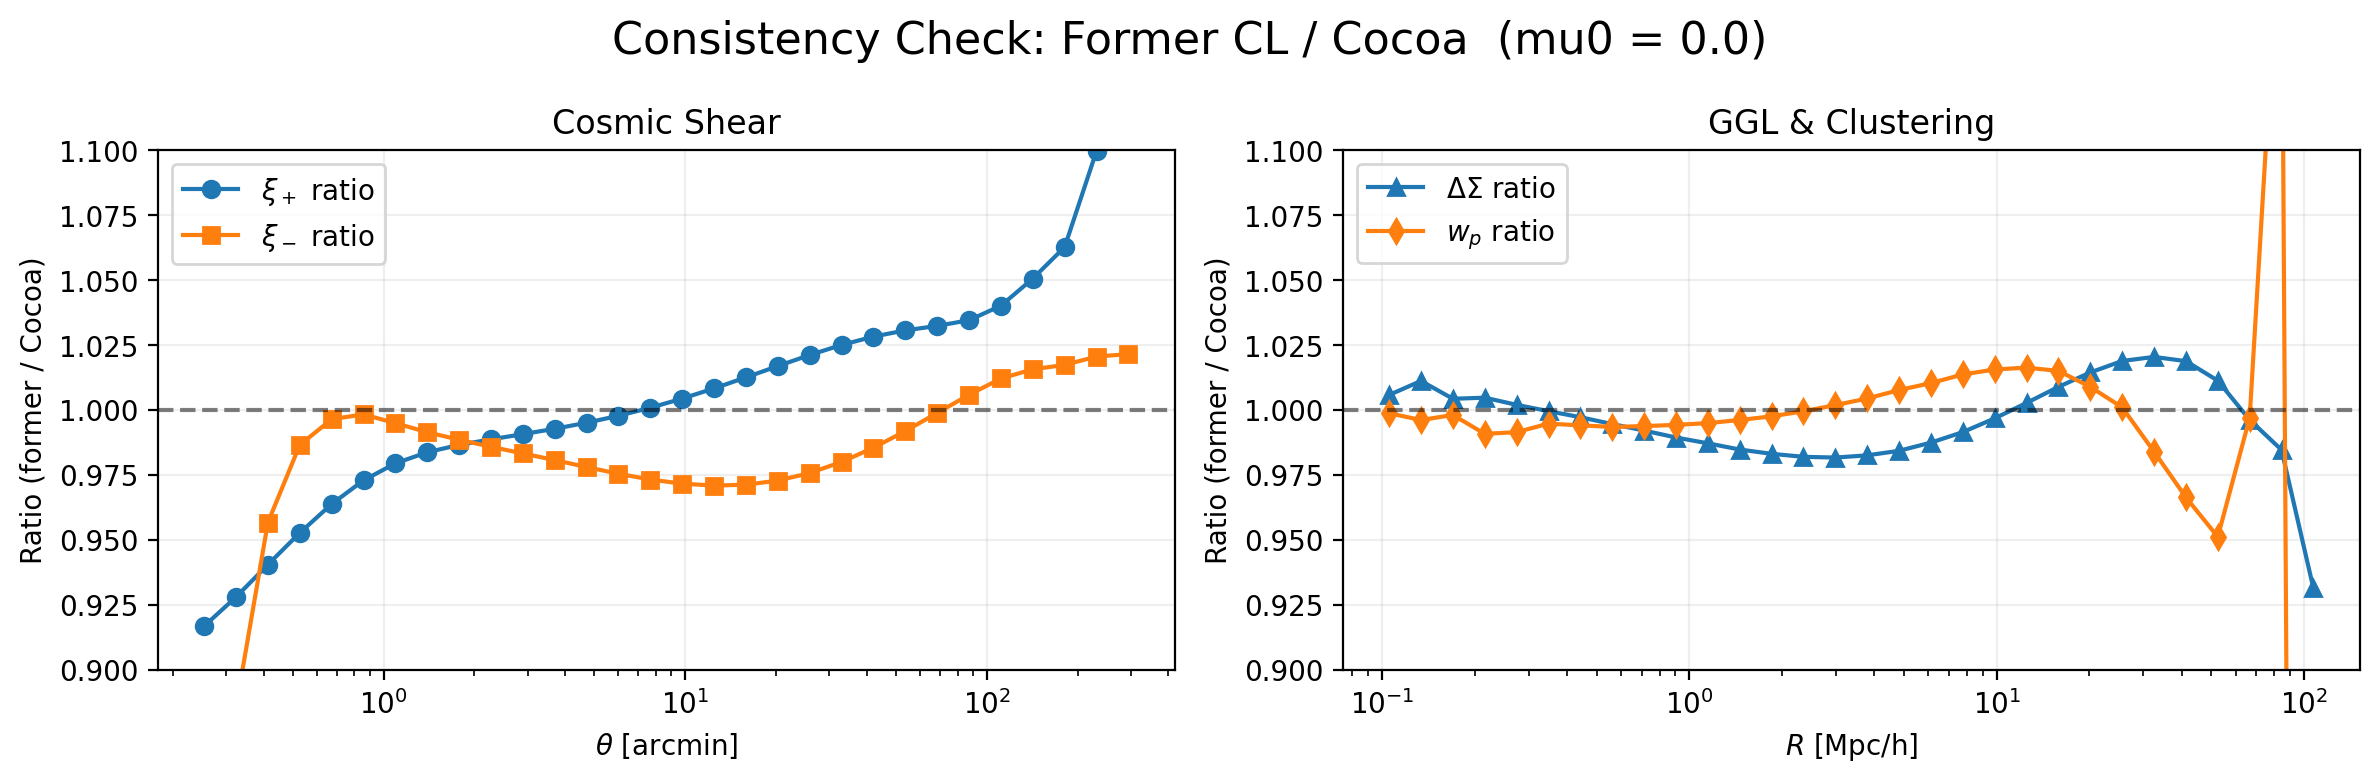

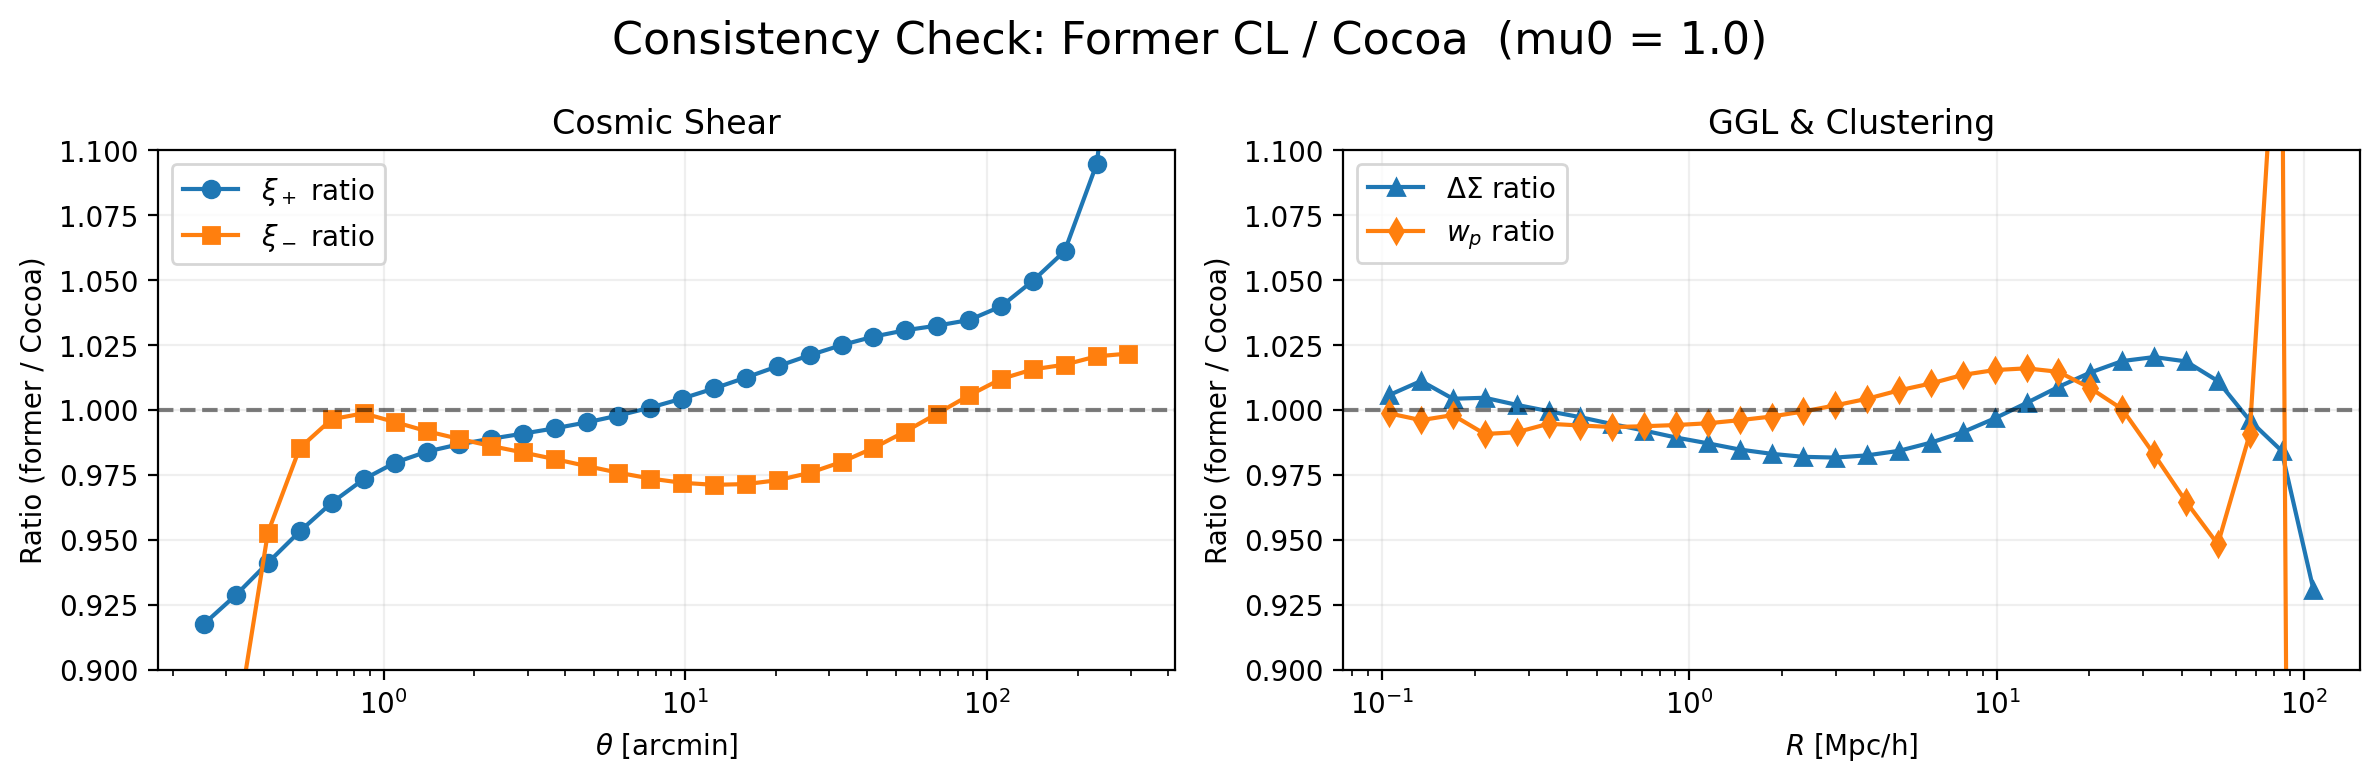

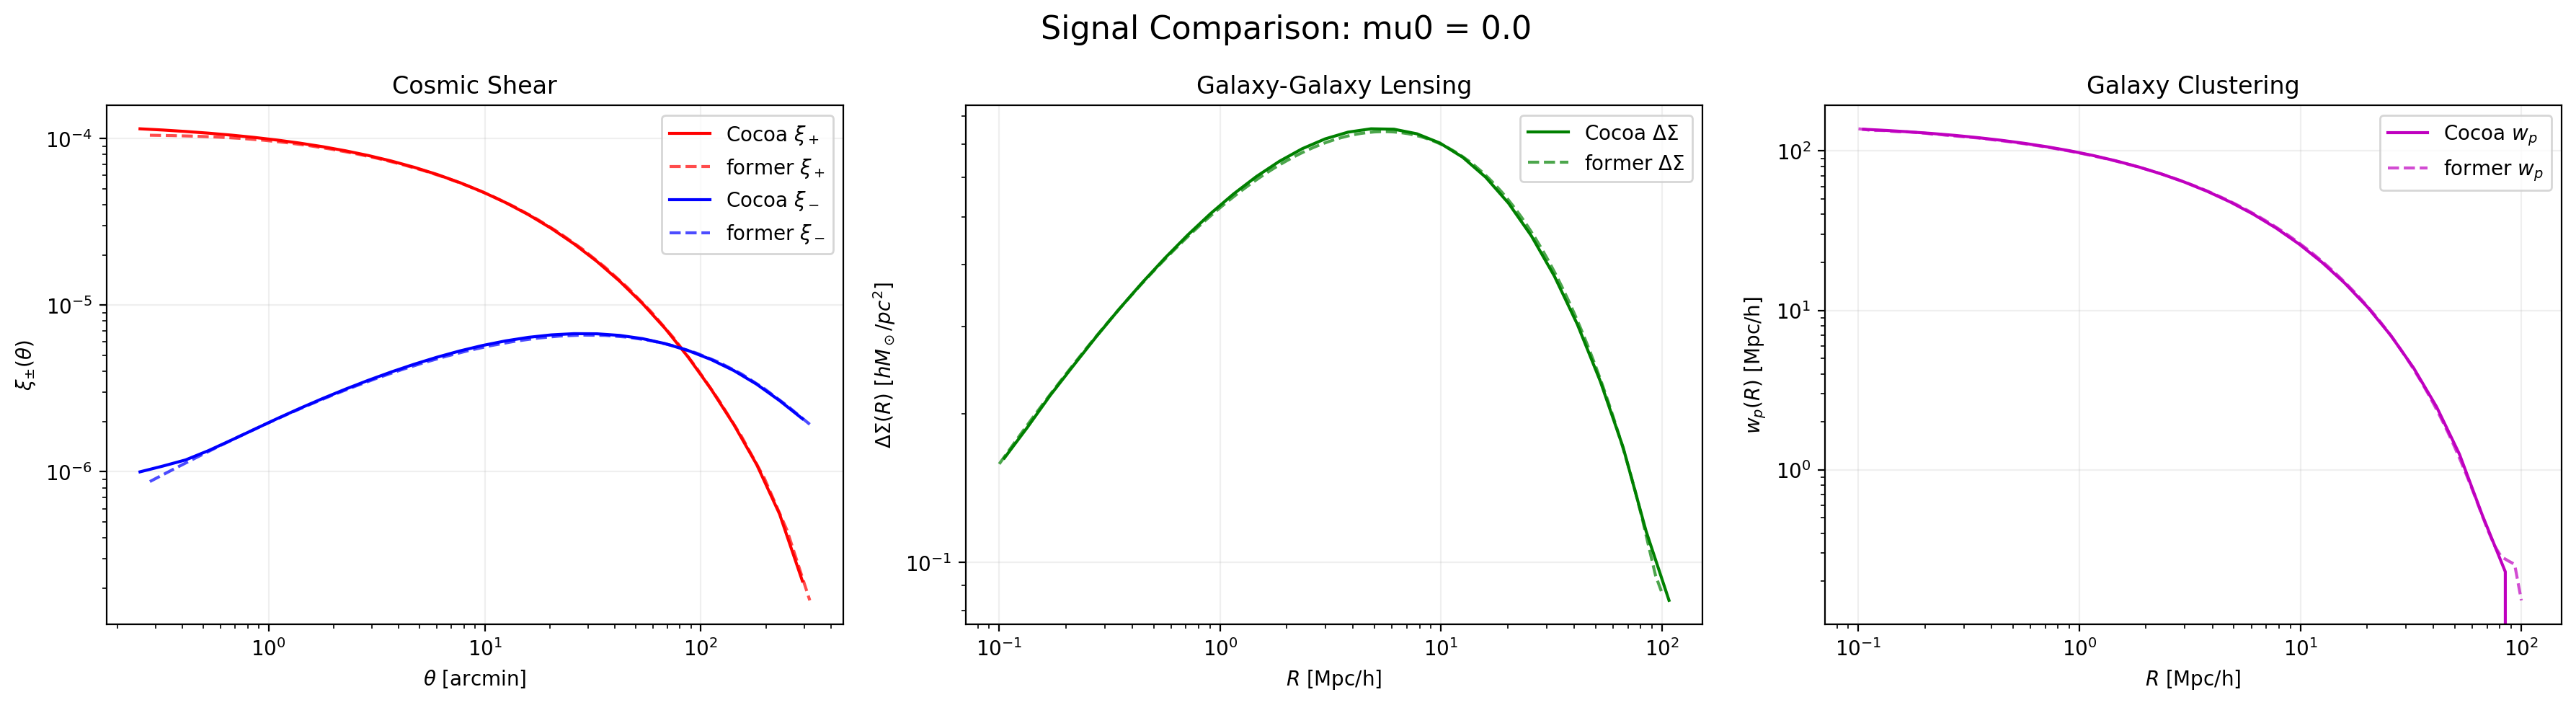

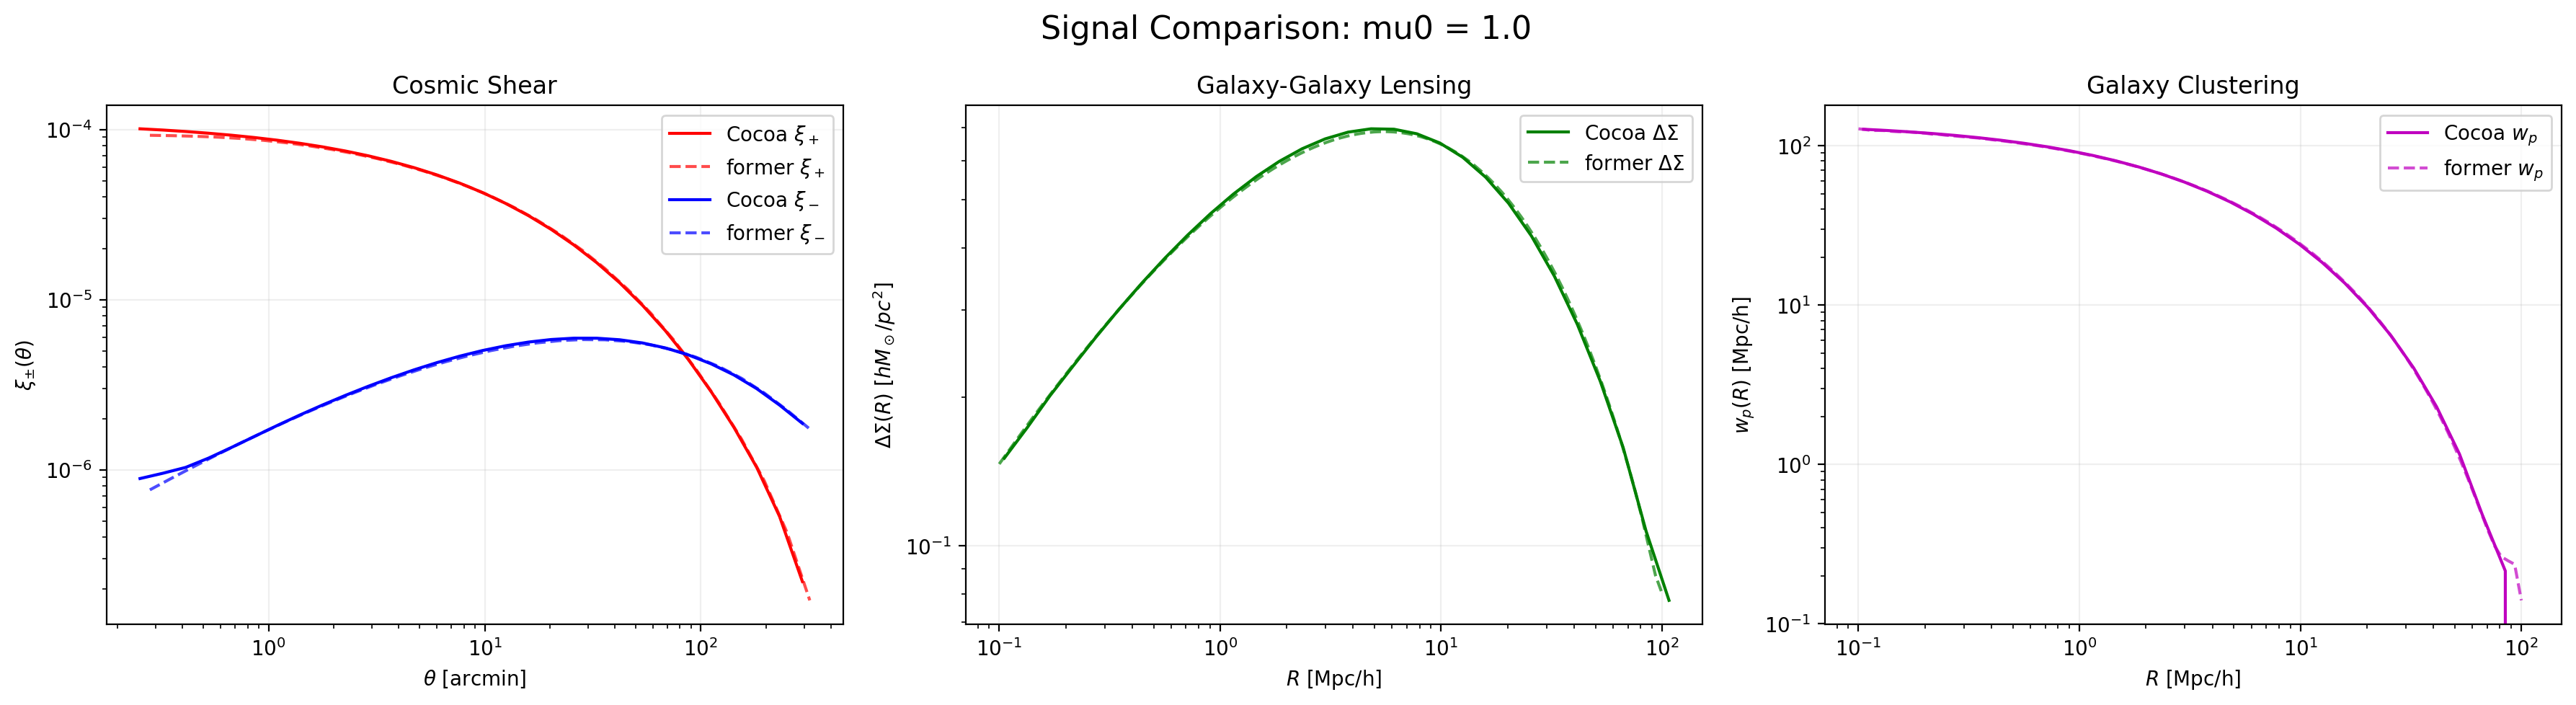

In [20]:
# dir(ci)
from scipy.interpolate import interp1d

# --- 1. パス設定 ---
SCRIPTS_DIR = "/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/scripts"

# --- 2. 読み込み・補間・比較の実行 ---
for mu0 in [0.0, 1.0]:
    tag = f"mu0_{mu0:.1f}"
    
    # Cocoa データのロード
    th_c, xip_c, xim_c = np.loadtxt(f"{SCRIPTS_DIR}/cocoa_theta_xip_xim_{tag}.dat", unpack=True)
    R_c, ds_c = np.loadtxt(f"{SCRIPTS_DIR}/cocoa_R_DS_{tag}.dat", unpack=True)
    Rwp_c, wp_c = np.loadtxt(f"{SCRIPTS_DIR}/cocoa_Rwp_wp_{tag}.dat", unpack=True)
    
    # Former CosmoLike データのロード
    th_f, xip_f, xim_f = np.loadtxt(f"{SCRIPTS_DIR}/former_xi_{tag}.dat", unpack=True)
    r_f, ds_f, wp_f = np.loadtxt(f"{SCRIPTS_DIR}/former_dswp_{tag}.dat", unpack=True)
    
    # Former の結果を Cocoa の bin に補間 (Interp)
    xip_i = interp1d(th_f, xip_f, bounds_error=False, fill_value="extrapolate")(th_c)
    xim_i = interp1d(th_f, xim_f, bounds_error=False, fill_value="extrapolate")(th_c)
    ds_i  = interp1d(r_f,  ds_f,  bounds_error=False, fill_value="extrapolate")(R_c)
    wp_i  = interp1d(r_f,  wp_f,  bounds_error=False, fill_value="extrapolate")(Rwp_c)
    
    # --- プロット作成 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # fig.suptitle(f"Consistency Check: Former CL / Cocoa  ({tag})", fontsize=16)
    fig.suptitle(f"Consistency Check: Former CL / Cocoa  (mu0 = {mu0:.1f})", fontsize=16)
    
    # 左側：Cosmic Shear (xi+, xi-)
    axes[0].plot(th_c, xip_i / xip_c, 'o-', label=r"$\xi_+$ ratio")
    axes[0].plot(th_c, xim_i / xim_c, 's-', label=r"$\xi_-$ ratio")
    axes[0].axhline(1.0, color='k', linestyle='--', alpha=0.5)
    axes[0].set_xscale('log')
    axes[0].set_xlabel(r"$\theta$ [arcmin]")
    axes[0].set_ylabel("Ratio (former / Cocoa)")
    axes[0].set_ylim(0.9, 1.1)
    axes[0].set_title("Cosmic Shear")
    axes[0].legend()
    axes[0].grid(alpha=0.2)
    
    # 右側：GGL & Clustering (DeltaSigma, w_p)
    axes[1].plot(R_c, ds_i / ds_c, '^-', label=r"$\Delta\Sigma$ ratio")
    axes[1].plot(Rwp_c, wp_i / wp_c, 'd-', label=r"$w_p$ ratio")
    axes[1].axhline(1.0, color='k', linestyle='--', alpha=0.5)
    axes[1].set_xscale('log')
    axes[1].set_xlabel(r"$R$ [Mpc/h]")
    axes[1].set_ylabel("Ratio (former / Cocoa)")
    axes[1].set_ylim(0.9, 1.1)
    axes[1].set_title("GGL & Clustering")
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# --- 1. パス設定 ---
SCRIPTS_DIR = "/home/tanida/cocoa_v41/cocoa/Cocoa/projects/mg_hsc_y3/scripts"

# --- 2. プロット実行 ---
for mu0 in [0.0, 1.0]:
    tag = f"mu0_{mu0:.1f}"
    
    # Cocoa データのロード
    th_c, xip_c, xim_c = np.loadtxt(f"{SCRIPTS_DIR}/cocoa_theta_xip_xim_{tag}.dat", unpack=True)
    R_c, ds_c = np.loadtxt(f"{SCRIPTS_DIR}/cocoa_R_DS_{tag}.dat", unpack=True)
    Rwp_c, wp_c = np.loadtxt(f"{SCRIPTS_DIR}/cocoa_Rwp_wp_{tag}.dat", unpack=True)
    
    # Former CosmoLike データのロード
    th_f, xip_f, xim_f = np.loadtxt(f"{SCRIPTS_DIR}/former_xi_{tag}.dat", unpack=True)
    r_f, ds_f, wp_f = np.loadtxt(f"{SCRIPTS_DIR}/former_dswp_{tag}.dat", unpack=True)
    
    # --- プロット作成 (3パネル構成) ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Signal Comparison: mu0 = {mu0:.1f}", fontsize=16)
    
    # (1) Cosmic Shear: xi+ and xi-
    axes[0].loglog(th_c, xip_c, 'r-', label=r"Cocoa $\xi_+$")
    axes[0].loglog(th_f, xip_f, 'r--', alpha=0.7, label=r"former $\xi_+$")
    axes[0].loglog(th_c, xim_c, 'b-', label=r"Cocoa $\xi_-$")
    axes[0].loglog(th_f, xim_f, 'b--', alpha=0.7, label=r"former $\xi_-$")
    axes[0].set_xlabel(r"$\theta$ [arcmin]")
    axes[0].set_ylabel(r"$\xi_{\pm}(\theta)$")
    # axes[0].set_xlim(5, 55)
    axes[0].set_title("Cosmic Shear")
    axes[0].legend()
    axes[0].grid(alpha=0.2)
    
    # (2) GGL: DeltaSigma
    axes[1].loglog(R_c, ds_c, 'g-', label=r"Cocoa $\Delta\Sigma$")
    axes[1].loglog(r_f, ds_f, 'g--', alpha=0.7, label=r"former $\Delta\Sigma$")
    axes[1].set_xlabel(r"$R$ [Mpc/h]")
    axes[1].set_ylabel(r"$\Delta\Sigma(R)$ [$h M_\odot / pc^2$]")
    # axes[1].set_ylim(5, 300)
    axes[1].set_title("Galaxy-Galaxy Lensing")
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    
    # (3) Clustering: w_p
    axes[2].loglog(Rwp_c, wp_c, 'm-', label=r"Cocoa $w_p$")
    axes[2].loglog(r_f, wp_f, 'm--', alpha=0.7, label=r"former $w_p$")
    axes[2].set_xlabel(r"$R$ [Mpc/h]")
    axes[2].set_ylabel(r"$w_p(R)$ [Mpc/h]")
    # axes[2].set_ylim(0.9, 1.1)
    axes[2].set_title("Galaxy Clustering")
    axes[2].legend()
    axes[2].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

### エラーバーのプロット

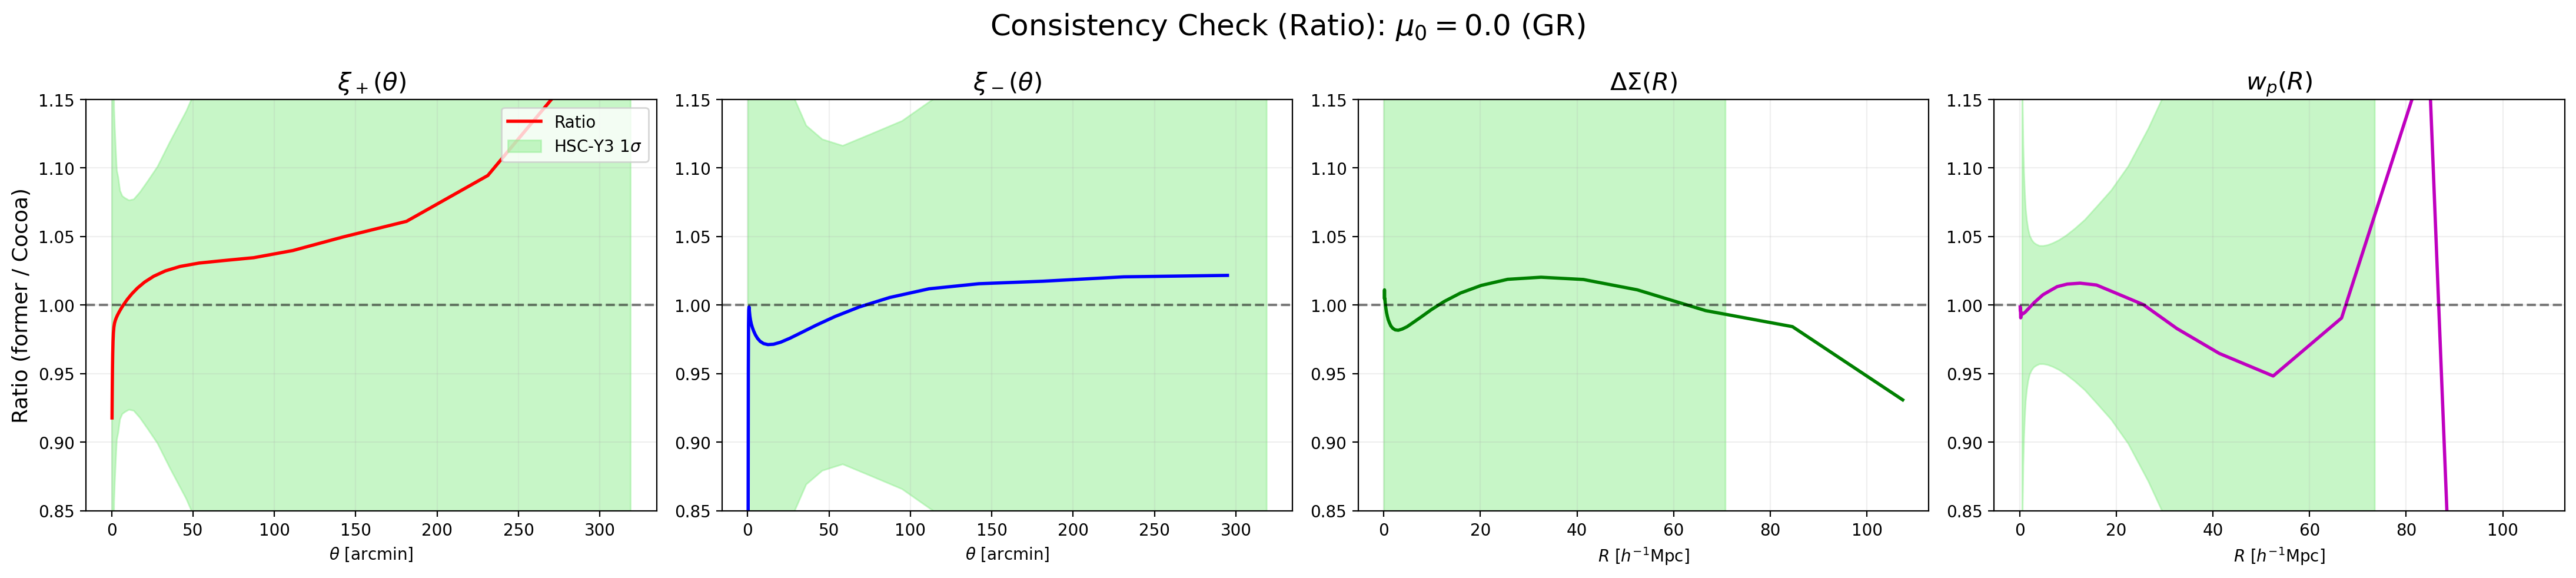

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. エラーデータの準備 ---
COV_DIR = "/home/tanida/GL/covariance"
cov = np.loadtxt(f"{COV_DIR}/covariance.dat")
err_diag = np.sqrt(np.diag(cov))

# 共分散行列のビン（x軸）
th_ref = np.loadtxt(f"{COV_DIR}/bin_xi_logcen.dat")
R_ref  = np.loadtxt(f"{COV_DIR}/bin_dSigma_logcen.dat")
Rwp_ref = np.loadtxt(f"{COV_DIR}/bin_wp_logcen.dat")

# エラー抽出
sig_ds_val  = err_diag[0:30]
sig_xip_val = err_diag[90:120]
sig_xim_val = err_diag[120:150]
sig_wp_val  = err_diag[150:180]

# --- 2. mu0 = 0.0 の信号で相対誤差を計算 ---
# Cocoaの信号（参照モデル）を共分散のビンに補間
xip_ref_signal = interp1d(th_c, xip_c, bounds_error=False, fill_value="extrapolate")(th_ref)
xim_ref_signal = interp1d(th_c, xim_c, bounds_error=False, fill_value="extrapolate")(th_ref)
ds_ref_signal  = interp1d(R_c,  ds_c,  bounds_error=False, fill_value="extrapolate")(R_ref)
wp_ref_signal  = interp1d(Rwp_c, wp_c, bounds_error=False, fill_value="extrapolate")(Rwp_ref)

# 相対誤差 (1-sigma)
err_rel_xip = sig_xip_val / xip_ref_signal
err_rel_xim = sig_xim_val / xim_ref_signal
err_rel_ds  = sig_ds_val  / ds_ref_signal
err_rel_wp  = sig_wp_val  / wp_ref_signal

# --- 3. プロット (mu0 = 0.0, linear scale) ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(r"Consistency Check (Ratio): $\mu_0 = 0.0$ (GR)", fontsize=18)

# (1) xi_plus
axes[0].fill_between(th_ref, 1 - err_rel_xip, 1 + err_rel_xip, color="lightgreen", alpha=0.5, label=r"HSC-Y3 1$\sigma$")
axes[0].plot(th_c, xip_i / xip_c, 'r-', lw=2, label="Ratio")
axes[0].set_title(r"$\xi_+(\theta)$", fontsize=15)
axes[0].set_xlabel(r"$\theta$ [arcmin]")

# (2) xi_minus
axes[1].fill_between(th_ref, 1 - err_rel_xim, 1 + err_rel_xim, color="lightgreen", alpha=0.5)
axes[1].plot(th_c, xim_i / xim_c, 'b-', lw=2)
axes[1].set_title(r"$\xi_-(\theta)$", fontsize=15)
axes[1].set_xlabel(r"$\theta$ [arcmin]")

# (3) DeltaSigma
axes[2].fill_between(R_ref, 1 - err_rel_ds, 1 + err_rel_ds, color="lightgreen", alpha=0.5)
axes[2].plot(R_c, ds_i / ds_c, 'g-', lw=2)
axes[2].set_title(r"$\Delta\Sigma(R)$", fontsize=15)
axes[2].set_xlabel(r"$R$ [$h^{-1}$Mpc]")

# (4) w_p
axes[3].fill_between(Rwp_ref, 1 - err_rel_wp, 1 + err_rel_wp, color="lightgreen", alpha=0.5)
axes[3].plot(Rwp_c, wp_i / wp_c, 'm-', lw=2)
axes[3].set_title(r"$w_p(R)$", fontsize=15)
axes[3].set_xlabel(r"$R$ [$h^{-1}$Mpc]")

# 共通設定 (xscaleはデフォルトのlinear)
for i, ax in enumerate(axes):
    ax.axhline(1.0, color='k', linestyle='--', alpha=0.5)
    ax.set_ylim(0.85, 1.15) 
    ax.grid(alpha=0.2)
    if i == 0: 
        ax.set_ylabel("Ratio (former / Cocoa)", fontsize=13)
        ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

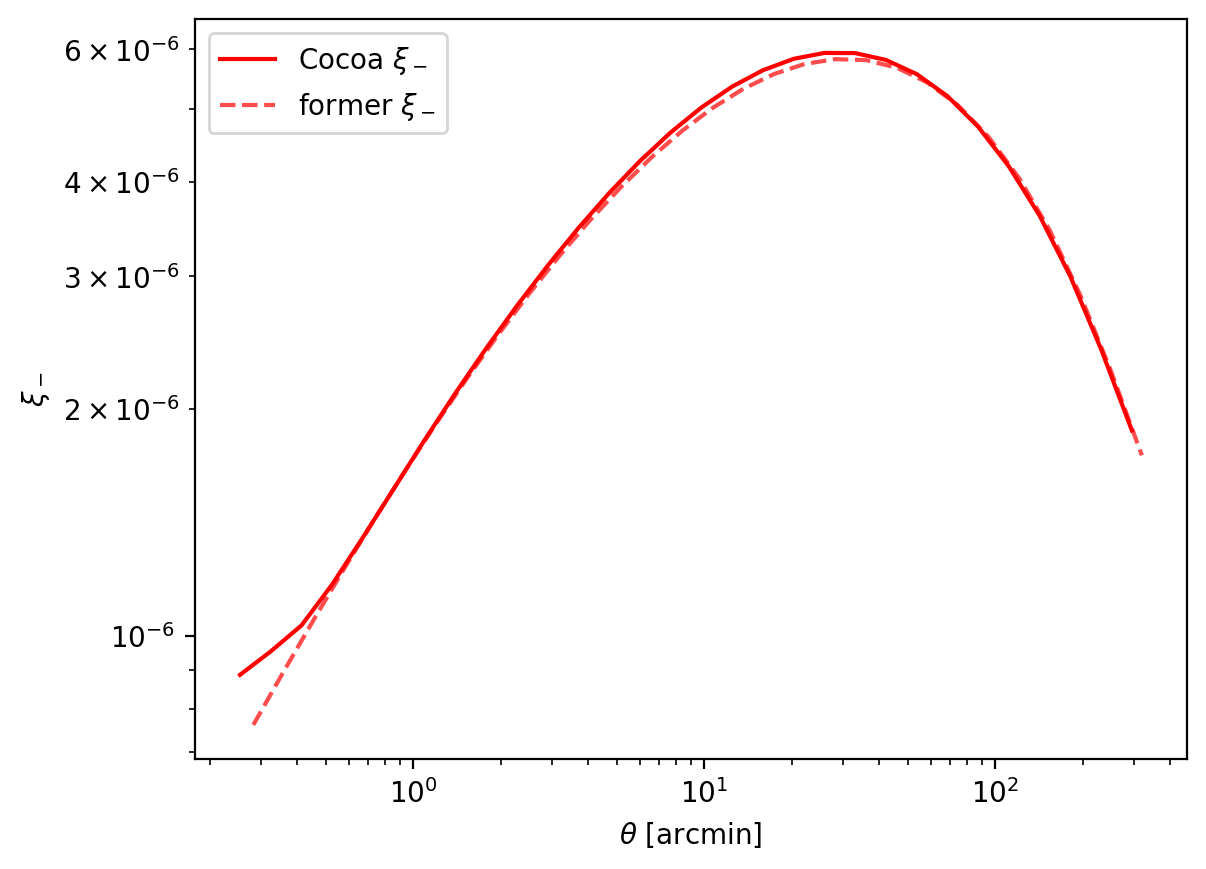

In [9]:
# plt.loglog(theta_sunao, xi_m_sunao, label = "sunao")
plt.loglog(th_c, xim_c, 'r-', label=r"Cocoa $\xi_-$")
plt.loglog(th_f, xim_f, 'r--', alpha=0.7, label=r"former $\xi_-$")

plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi_-}(\theta)$")

plt.legend()

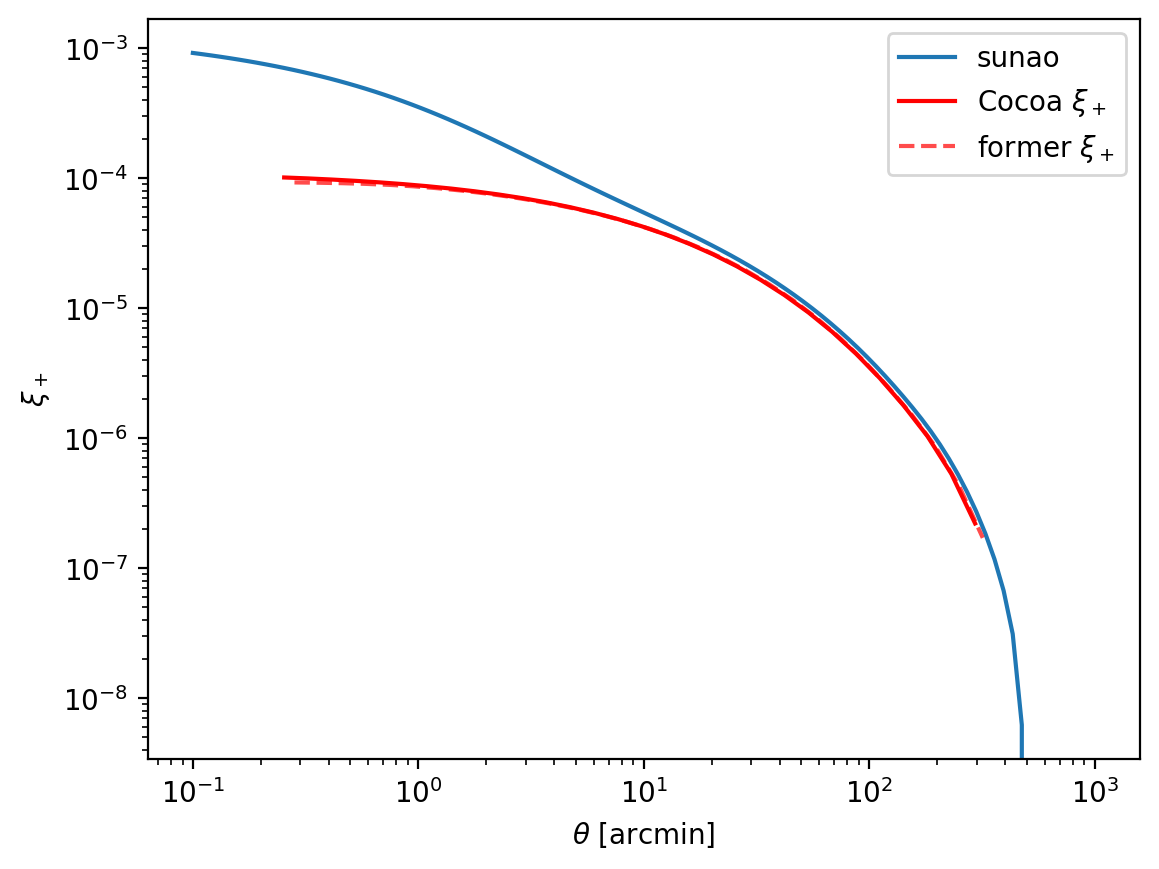

In [12]:
theta_sunao, xi_p_sunao = np.loadtxt("/home/tanida/cocoa_v41/external_ref_data/theta_xip_stackedpofz_dempz.dat", unpack = True)
theta_sunao, xi_m_sunao = np.loadtxt("/home/tanida/cocoa_v41/external_ref_data/theta_xim_stackedpofz_dempz.dat", unpack = True)
theta_sunao_bin, xi_p_sunao_bin = np.loadtxt("/home/tanida/cocoa_v41/external_ref_data/theta_xip_stackedpofz_dempz_binave.dat", unpack = True)
theta_sunao_bin = theta_sunao_bin * np.exp(0.242413/2) 


plt.loglog(theta_sunao, xi_p_sunao, label = "sunao")
# plt.loglog(theta_sunao_bin, xi_p_sunao_bin, label = "sunao with bin")
plt.loglog(th_c, xip_c, 'r-', label=r"Cocoa $\xi_+$")
plt.loglog(th_f, xip_f, 'r--', alpha=0.7, label=r"former $\xi_+$")

plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi_+}(\theta)$")

plt.legend()

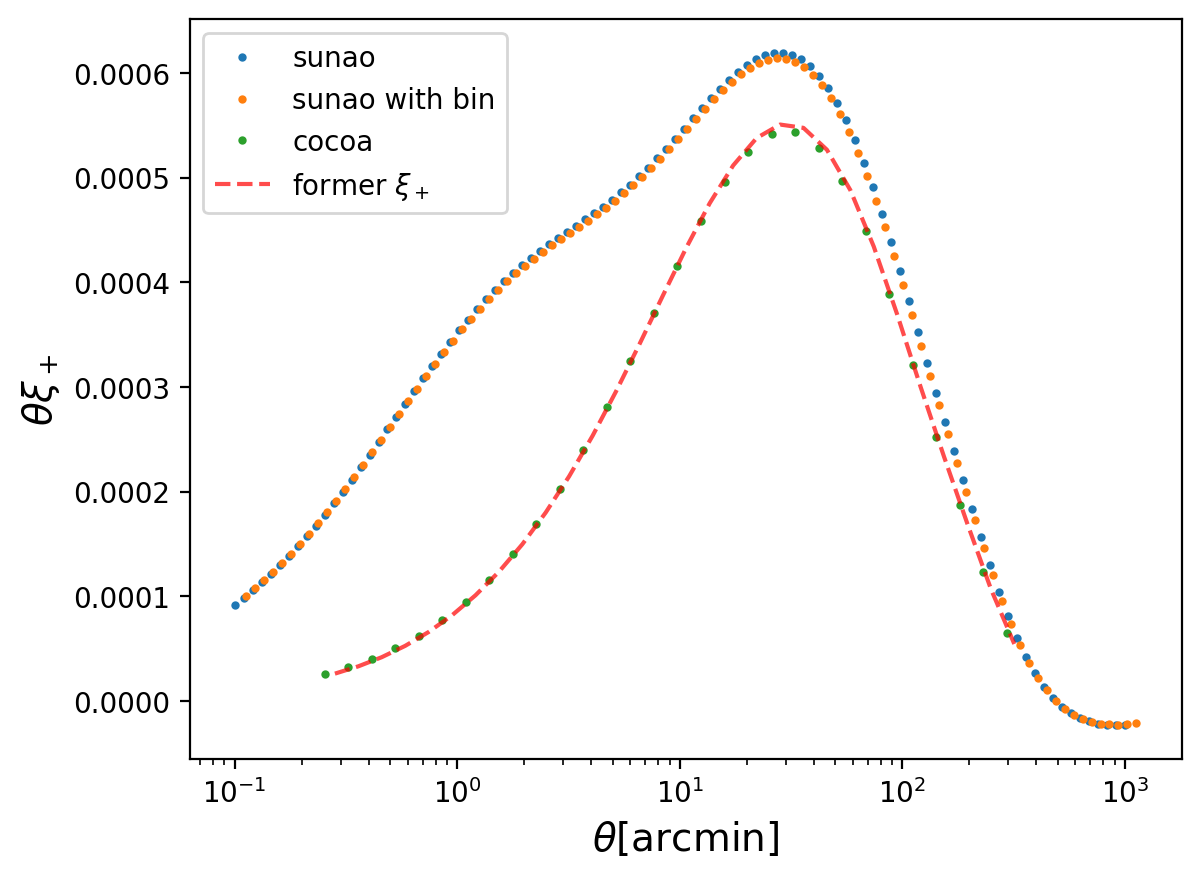

In [13]:
# plt.plot(theta, theta*xip[:,9], "o", markersize = 2, label = "COCOA")
plt.plot(theta_sunao, theta_sunao*xi_p_sunao, "o", markersize = 2, label = "sunao")
plt.plot(theta_sunao_bin, theta_sunao_bin*xi_p_sunao_bin, "o", markersize = 2, label = "sunao with bin")

plt.plot(th_c, xip_c*th_c, "o", markersize = 2, label = "cocoa")
plt.plot(th_f, xip_f*th_f, 'r--', alpha=0.7, label=r"former $\xi_+$")


#plt.loglog(theta_CL_flat/0.6732, theta_CL_flat*xip_CL_flat*0.6732, "o", label = "Yuji addjusted by h")
#plt.loglog(theta_CL_flat, theta_CL_flat*xip_CL_flat, label = "Yuji")
plt.xlabel(r"$\theta$[arcmin]", fontsize=14)
plt.ylabel(r"$\theta\xi_+$", fontsize=14)
plt.xscale("log")
plt.legend()